# Orbyts Session 7: Black Hole Shadows

In previous sessions, we learned:
- that gravity can be described as the curvature of spacetime
- how distances between points are a way to describe the curvature mahtematically
- that an object called the _metric_ ($ds^2$) describes these distances mathematically

Recall that flat spacetime is described by the __Minkowski__ metric:

$ds^2 = -c^2 dt^2 + dx^2 + dy^2 + dz^2$

While the curved spacetime outside spherical objects is described by the 
__Schwarzschild__ metric:

$ds^2 = -c^2(1-\frac{2GM}{c^2r})dt^2 + dr^2/(1-\frac{2GM}{c^2r}) +r^2 d\theta^2 + r^2 \sin^2 \theta d\phi^2$ 

A reminder of the symbols in these metrics:
- $ds^2$ is the metric itself
- $c$ is the speed of light, to make units work
- $t$ is time, $dt$ is the change in time
- $x$ $y$, and $z$ are 3D _Cartesian_ coordinates
- $G$ is Newtons gravitational constant
- $M$ is the mass of the spherical object
- $r$ is the radius, or distance from the centre of the object
- $\theta$ and $\phi$ are the spherical polar angles (don't worry too much about these)

From this metric we can define a special distance called the __Schwarzschild radius__, defined as:

$R_s = \frac{2GM}{c^2}$

We can calculate a Schwarzschild radius for every spherical object. If an object 
is smaller than its own Schwarzchild radius, it will have an _event horizon_ and 
we call it a __Black Hole__. The event horizon is a boundary beyond which nothing
can escape. This is because the factor in front of $dr^2$ in the Schwarzschild
metric changes sign, which makes the radius timelike: we can only travel in one 
direction, which is towards the centre of the black hole.

Note that with the definition of the Schwarzschild radius we can write the
Schwarzdchild metric in a slightly simpler form:

$ds^2 = -c^2 (1-\frac{R_s}{r})dt^2 + dr^2 / (1-\frac{R_s}{r}) +r^2 d\theta^2 + r^2 \sin^2 \theta d\phi^2$

Convince yourself that this is the same as the earlier definition!


## Modified Black Holes

The Schwarzschild metric is the metric describing spherical objects (like black 
holes) in General Relativiy (Einstein's theory of gravity). However, this might
not be the correct theory. In other theories of gravity, the curvature around
black holes might look different. In general, (by definition) a black hole has
a metric of the form:

$ds^2 = -c^2 A(r)dt^2 + \frac{dr^2}{B(r)} +r^2 d\theta^2 + r^2 \sin^2 \theta d\phi^2$ .

Note that this is very similar to the Schwarzschild metric, but we now have two
general functions of radius $A(r)$ and $B(r)$. These functions will have zeros, 
indicating an event horizon. We find these functions using the _differential_ 
equations governing the theory (don't worry too much about this, you won't have 
to solve this type of equation). If we do this in general relativity, we find
the Schwarzschild metric, which is a special case of the metric above.

__*By comparing the two metrics, write down A(r) and B(r) for the Schwarzschild metric.*__

We will later study black holes in alternative theories of gravity where $A(r)$ 
and $B(r)$ take different forms.

We will study black hole shadows using the orbyts-black-hole-shadows python
package and this notebook aims to get you familiar with the functionalities in
this package. The below two cells install and import the main objects 
(_classes_) from the package.

In [ ]:
#pip install orbyts_black_hole_shadows

In [1]:
from orbyts_black_hole_shadows.utils import Metric
from orbyts_black_hole_shadows.sources import Source, Box

We can use the __`Metric()`__ class to define a black hole metric. Let's use it
to define the Schwarzschild metric. In the cell below, finish the code to define
 $A(r)$ and $B(r)$ as python functions. Do this in units of the Schwarzschild
 radius. (i.e. set $R_s = 1$).

In [5]:
# Complete this code and run the cell

def A(r):
    return 1-1/r# Enter code here

# Enter code for B(r) here
def B(r):
    return 1-1/r

# No need to modify anything below here
def dAdr(r):
    return 1/r**2

def dBdr(r):
    return 1/r**2

In [6]:
# TEST - Run this cell but don't modify it
try:
    if (A(2) - 0.5 < 1e-5) and (B(4) - 0.75 < 1e-5):
        print("That is correct, well done!")
    else:
        print("Not quite, try again!")
except:
    print("Not quite, try again!")

That is correct, well done!


The dAdr and dBdr functions are the _derivatives_ $\frac{dA}{dr}$ and 
$\frac{dB}{dr}$ of $A(r)$ and $B(r)$. If you know how to take a derivative, see
if you can understand how these functions are calculated. Otherwise, don't worry
about it. We then pass these functions to a new __`Metric()`__ object in the
cell below.

In [7]:
# Run this cell

schwarzschild_metric = Metric(A, B, dAdr, dBdr)

The metric functions $A$ and $B$ are _attributes_ of this __`Metric()`__ object.
For example, we can get the $A$ function by writing schwarzschild_metric.A

In the code cell below, use the schwarzschild_metric attributes to calculate B(5)

In [ ]:
# Write your code below


## Black Hole Shadows

The picture below shows the image taken by the event horizon telescope of M87*.
__*What do you see in this picture? Where do you think the light is coming from?*__

<img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.science-et-vie.com%2Fwp-content%2Fuploads%2Fscienceetvie%2F2023%2F05%2Ftrou-noir-scaled.jpg&f=1&nofb=1&ipt=8b3428d2cf0bb77ba4c66db55cbbf872b40d095343e5d68162a1af5b9c09495e">

Because black holes do not emit light, we cannot see them directly. However, if
there is some light source near them, we can know that the black hole is there
by studying how the light gets bent around it by gravity. Because this is similar
to studying an object by only studying its shadow, we call the resulting image a 
_black hole shadow_. In this section, we will learn a bit more about the most
important features of a black hole shadow, while using the orbyts-black-hole-shadows code.

Firstly, we will use the __`Box()`__ class to define a box in which to calculate
the light trajectories around a black hole in the centre. Note that everything
is in units of Schwarschild radius (so for example a distance of 3 means a 
distance of 3 Schwarzschild radii). To define a box we need to specify a box_size
(the length of each side of the box, which is a cube) and the the amount of points
inside the box (we will discuss that later). The code below defines a box of size 10: 

In [3]:
# Run this cell
box = Box(box_size=10, box_points=50)

To calculate the photon trajectories in this box, we can use the method 
`.calculate_photon_rays()` and we then use the method `.plot_box_orbits()` to plot
these photon rays as below:

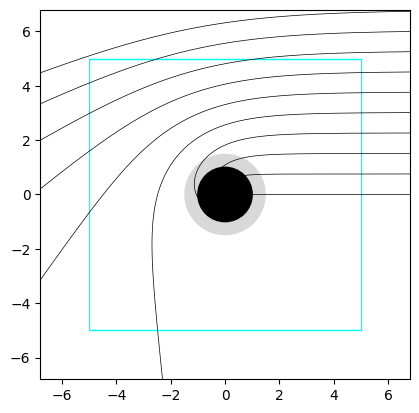

In [10]:
# Run this cell
box.calculate_photon_rays(n_b=10, metric=schwarzschild_metric, D=1000, b_max=6.8)
box.plot_box_orbits()

The arguments of the `.calculate_photon_rays()` method are:
- __n_b__, this is the number of photon rays to calculate. In the end, we want
this to be as high as possible, but this will also cause the code to take very 
long to run.
- __metric__, since the trajectories of the photons depend on the curvature
around the black hole, we need to specify which metric we use. In this case we 
have used the Schwarzschild metric from general relativity.
- __D__, the code calculates all the photon rays that arrive parallel at a
distance D from the black hole. As you can see this is to the right of the black
hole in the image. We want to choose this value to be very far away from the
black hole. In this case we have chosen $D=1000$, which means $1000$
Schwarzschild radii away from the black hole.
- __b_max__ we will learn about the _impact parameter_ $b$ later on, but this is
essentially the height of the photon ray when it crosses the distance $D$.
__b_max__ is the maximum height for which we want to calculate a photon ray. We
have chosen $6.8$ (Schwarzschild radii) in the code above.